In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 1. Load Cleaned Data
df = pd.read_csv('lending_data_cleaned.csv')

In [3]:
# 2. Advanced Feature Engineering
print("Adding interaction features...")
df['payment_to_income'] = df['installment'] / ((df['annual_inc'] / 12) + 1)
df['loan_to_income'] = df['loan_amnt'] / (df['annual_inc'] + 1)

Adding interaction features...


In [4]:
# 3. Encoding Categorical Variables
print("Encoding categorical features...")
# Ordinal mapping for sub_grade
sorted_subgrades = sorted(df['sub_grade'].unique())
subgrade_mapping = {grade: index for index, grade in enumerate(sorted_subgrades, start=1)}
df['sub_grade'] = df['sub_grade'].map(subgrade_mapping)

Encoding categorical features...


In [5]:
# One-Hot Encoding
dummies = pd.get_dummies(df[['home_ownership', 'verification_status', 'purpose_group']], drop_first=True, dtype=int)
df = pd.concat([df.drop(['home_ownership', 'verification_status', 'purpose_group'], axis=1), dummies], axis=1)

In [6]:
# 4. Train/Test Split & Scaling
print("Splitting and scaling data...")
X = df.drop('default', axis=1)
y = df['default']

Splitting and scaling data...


In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
# 5. Train the Ultimate XGBoost Model
print("Training Tuned XGBoost Model...")
ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)

# Using the best parameters from your RandomizedSearchCV
best_xgb = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.2,
    gamma=1,
    colsample_bytree=1.0,
    subsample=1.0,
    scale_pos_weight=ratio,
    random_state=42,
    eval_metric='logloss'
)
best_xgb.fit(X_train_scaled, y_train)

Training Tuned XGBoost Model...


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=1,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.2, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [10]:
# 6. Evaluation
y_pred = best_xgb.predict(X_test_scaled)
print("\n--- ULTIMATE XGBoost Classification Report ---")
print(classification_report(y_test, y_pred))


--- ULTIMATE XGBoost Classification Report ---
              precision    recall  f1-score   support

           0       0.94      0.82      0.87     17201
           1       0.51      0.78      0.62      4190

    accuracy                           0.81     21391
   macro avg       0.72      0.80      0.74     21391
weighted avg       0.85      0.81      0.82     21391



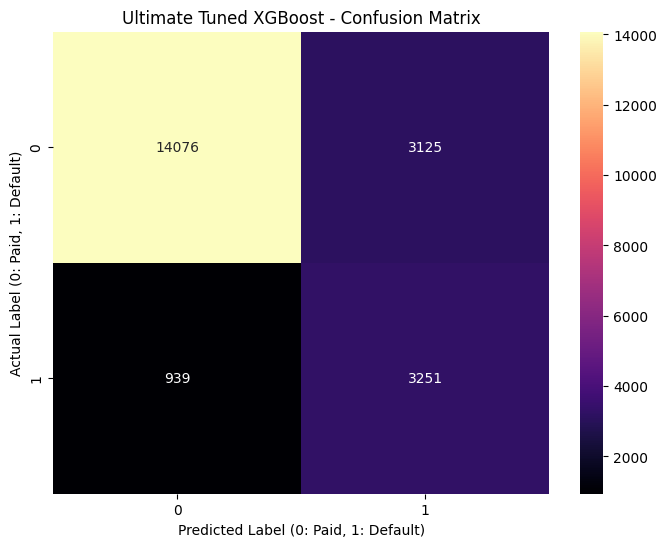

In [11]:
# 7. Confusion Matrix Plot
plt.figure(figsize=(8, 6))
cm_ult = confusion_matrix(y_test, y_pred)
sns.heatmap(cm_ult, annot=True, fmt='d', cmap='magma')
plt.title('Ultimate Tuned XGBoost - Confusion Matrix')
plt.ylabel('Actual Label (0: Paid, 1: Default)')
plt.xlabel('Predicted Label (0: Paid, 1: Default)')
plt.show()

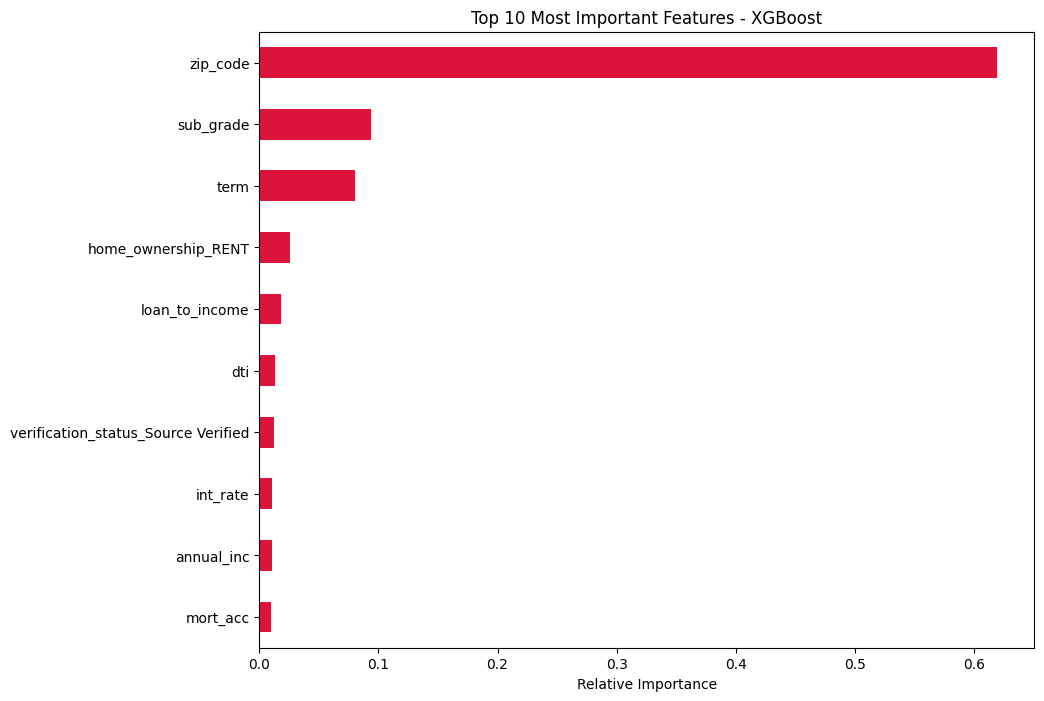

In [12]:
# 8. Feature Importance Plot
plt.figure(figsize=(10, 8))
feature_importances = pd.Series(best_xgb.feature_importances_, index=X.columns)
feature_importances.nlargest(10).sort_values().plot(kind='barh', color='crimson')
plt.title('Top 10 Most Important Features - XGBoost')
plt.xlabel('Relative Importance')
plt.show()